# putEMG — Deep Learning Model Training & Evaluation

Trains and evaluates 5 CNN architectures on the putEMG gesture dataset using
**Leave-One-Subject-Out (LOSO)** cross-validation.

| # | Model | Description |
|---|-------|-------------|
| 1 | **EEGNet** | Depthwise separable CNN, original baseline |
| 2 | **ShallowConvNet** | Temporal + spatial conv, square/log nonlinearity |
| 3 | **DeepConvNet** | 4 stacked conv blocks, increasing filter depth |
| 4 | **CNN_LSTM** | Spatial CNN → temporal pooling → 2-layer LSTM |
| 5 | **EMG_TCN** | Spatial mixing + 4 dilated temporal conv blocks |

**LOSO split (per fold):**
- **Test** — 1 held-out subject (never seen during training)
- **Dev** — 1 fixed subject (last in the list) used only for early stopping
- **Train** — all remaining subjects

Control how many folds to run with `N_FOLDS` in the config cell.
Set `N_FOLDS = 1` for a quick dev run; `N_FOLDS = None` for full LOSO over all subjects.

> **Prerequisites**: Run `preprocessing_driver.ipynb` first to generate per-subject `.mat` files.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

In [26]:
# -- Shared utilities (public/) --
sys.path.append(os.path.abspath("../../../../"))
import public.deep_learning_models as dlm
from public.emg_loader import BCIDataset, load_all_subjects, make_loso_loaders, loso_folds, generate_loso_configs

In [22]:
# -- Config --
DATA_DIR   = '/Volumes/KRIS/data/UG_per_subject'
BATCH_SIZE = 16
subjects = load_all_subjects(DATA_DIR)

Loading 44 subject file(s) from: /Volumes/KRIS/data/UG_per_subject

  → emg_gestures_03_U.mat  (280 samples)
  → emg_gestures_04_U.mat  (280 samples)
  → emg_gestures_05_U.mat  (280 samples)
  → emg_gestures_06_U.mat  (280 samples)
  → emg_gestures_07_U.mat  (280 samples)
  → emg_gestures_08_U.mat  (280 samples)
  → emg_gestures_09_U.mat  (280 samples)
  → emg_gestures_10_U.mat  (280 samples)
  → emg_gestures_11_U.mat  (280 samples)
  → emg_gestures_12_U.mat  (280 samples)
  → emg_gestures_13_U.mat  (280 samples)
  → emg_gestures_14_U.mat  (280 samples)
  → emg_gestures_15_U.mat  (280 samples)
  → emg_gestures_16_U.mat  (280 samples)
  → emg_gestures_17_U.mat  (280 samples)
  → emg_gestures_18_U.mat  (280 samples)
  → emg_gestures_19_U.mat  (280 samples)
  → emg_gestures_20_U.mat  (280 samples)
  → emg_gestures_22_U.mat  (280 samples)
  → emg_gestures_23_U.mat  (280 samples)
  → emg_gestures_24_U.mat  (280 samples)
  → emg_gestures_25_U.mat  (280 samples)
  → emg_gestures_26_U.mat  (28

In [23]:
# ── Training & evaluation utilities ─────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total


def evaluateFinal(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    actual    = torch.tensor([], dtype=torch.int64)
    predicted = torch.tensor([], dtype=torch.int64)
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X).argmax(dim=1)
            correct   += (pred == y).sum().item()
            total     += y.size(0)
            actual    = torch.cat((actual,    y.cpu()),    dim=0)
            predicted = torch.cat((predicted, pred.cpu()), dim=0)

        print(np.unique(predicted.numpy(), return_counts=True))
        cm = confusion_matrix(actual.numpy(), predicted.numpy())
        ConfusionMatrixDisplay(cm).plot()

    print(f'The accuracy for the test is {(correct / total) * 100:.2f}%')
    return correct / total

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [29]:
# ── LOSO ──────────────────────────────────────────────────────────────────────
N_FOLDS = 1        # folds to run — each fold uses a different random test/dev subject
SEED    = 42       # random seed for fold generation (set to None for a new draw each run)

# ── Training ──────────────────────────────────────────────────────────────────
MAX_EPOCHS = 20
PATIENCE   = 5     # early-stopping patience (epochs without improvement)
MIN_DELTA  = 0.002  # minimum improvement to reset patience

# ── Hyperparameters ───────────────────────────────────────────────────────────
DROPOUT = 0.1
LR      = 1e-3

# ── Weights output ────────────────────────────────────────────────────────────
WEIGHTS_DIR = 'weights'

---
## Training

Each model is trained on each LOSO fold with:
- **Early stopping** — stops when val accuracy doesn't improve by `MIN_DELTA` for `PATIENCE` epochs
- **ReduceLROnPlateau** — halves the LR when val accuracy plateaus for 5 epochs
- **Best-state checkpointing** — restores the best-val-acc weights before test evaluation

Results are collected per fold. After all folds, mean ± std accuracy is reported per model.

In [30]:
model_registry = {
    'EEGNet':         lambda: dlm.EEGNet(dropout_rate=DROPOUT),
    'ShallowConvNet': lambda: dlm.ShallowConvNet(dropout_rate=DROPOUT),
    # 'DeepConvNet':    lambda: dlm.DeepConvNet(dropout_rate=DROPOUT),
    # 'CNN_LSTM':       lambda: dlm.CNN_LSTM(dropout_rate=DROPOUT),
    'EMG_TCN':        lambda: dlm.EMG_TCN(dropout_rate=DROPOUT) # takes long for some reason
}

In [31]:
# Initialise accumulators (reset every time this cell runs)
fold_results = {name: [] for name in model_registry}
best_states  = {name: (0.0, None) for name in model_registry}

# Generate random, non-overlapping (test, dev) pairs
loso_configs = generate_loso_configs(subjects, n_folds=N_FOLDS, seed=SEED)

Generated 1 LOSO fold(s) (seed=42):
  Fold 1: test=emg_gestures_12_U.mat  dev=emg_gestures_27_U.mat



In [32]:
loso_configs

[(0, 9, 23)]

In [33]:
for fold_idx, test_idx, dev_idx in loso_configs:

    test_name, train_loader, dev_loader, test_loader = loso_folds(
        subjects, test_subject_idx=test_idx, dev_subject_idx=dev_idx
    )

    print(f"\n{'#'*60}")
    print(f"  FOLD {fold_idx + 1}/{N_FOLDS}  —  test subject: {test_name}")
    print(f"{'#'*60}")

    for name, build_fn in model_registry.items():
        print(f"\n{'='*50}")
        print(f"  Training: {name}")
        print(f"{'='*50}")

        model     = build_fn().to(device)
        optimizer = optim.Adam(model.parameters(), lr=LR)
        scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                      patience=5, min_lr=1e-6)
        criterion = nn.CrossEntropyLoss()

        best_val_acc = float('-inf')
        best_state   = None
        bad_epochs   = 0

        for epoch in range(MAX_EPOCHS):
            tr_loss  = train(model, train_loader, criterion, optimizer, device)
            val_acc  = evaluate(model, dev_loader, device)
            curr_lr  = optimizer.param_groups[0]['lr']

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

            scheduler.step(val_acc)

            if val_acc >= (best_val_acc - MIN_DELTA):
                bad_epochs = 0
            else:
                bad_epochs += 1

            print(f"  Epoch {epoch+1:3d}: loss={tr_loss:.4f}  dev={val_acc*100:.2f}%  "
                  f"best={best_val_acc*100:.2f}%  lr={curr_lr:.2e}")

            if bad_epochs >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

        model.load_state_dict(best_state)

        print(f"\n  --- {name} | Fold {fold_idx+1} — Test Evaluation ---")
        test_acc = evaluateFinal(model, test_loader, device)
        fold_results[name].append(test_acc)

        if test_acc > best_states[name][0]:
            best_states[name] = (test_acc, best_state)

─ LOSO fold — testS ID: 9, valS ID: 23 ──────────────────────
  Test  : emg_gestures_12_U.mat  — 280 samples
  Dev   : emg_gestures_27_U.mat   — 280 samples
  Train : 42 subjects, 11760 samples total


############################################################
  FOLD 1/1  —  test subject: emg_gestures_12_U.mat
############################################################

  Training: EEGNet
  Epoch   1: loss=1.0197  dev=76.79%  best=76.79%  lr=1.00e-03
  Epoch   2: loss=0.6999  dev=92.14%  best=92.14%  lr=1.00e-03
  Epoch   3: loss=0.5976  dev=93.21%  best=93.21%  lr=1.00e-03


KeyboardInterrupt: 

---
## Results Summary


Model               Folds    Mean Acc       Std  Per-fold results
---------------------------------------------------------------------------
EEGNet                  2      85.89%     0.18%  [85.7%  86.1%]
ShallowConvNet          2      70.00%     3.93%  [73.9%  66.1%]
EMG_TCN                 1      81.79%     0.00%  [81.8%]


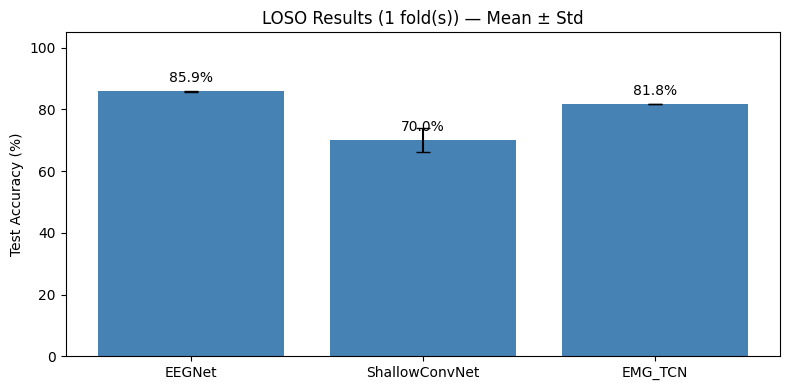

In [13]:
print(f"\n{'Model':<18} {'Folds':>6}  {'Mean Acc':>10}  {'Std':>8}  {'Per-fold results'}")
print('-' * 75)
for name in model_registry:
    accs = [a * 100 for a in fold_results[name]]
    if accs:
        mean, std = np.mean(accs), np.std(accs)
        fold_str  = '  '.join(f"{a:.1f}%" for a in accs)
        print(f"{name:<18} {len(accs):>6}  {mean:>9.2f}%  {std:>7.2f}%  [{fold_str}]")
    else:
        print(f"{name:<18} {'—':>6}  {'—':>10}  {'—':>8}")

# Bar chart — mean accuracy per model (only models with results)
names_with_results = [n for n in model_registry if fold_results[n]]
means = [np.mean(fold_results[n]) * 100 for n in names_with_results]
stds  = [np.std(fold_results[n])  * 100 for n in names_with_results]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names_with_results, means, yerr=stds, capsize=5, color='steelblue')
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title(f'LOSO Results ({N_FOLDS} fold(s)) — Mean ± Std')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{m:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
## Save Best Model Weights

In [14]:
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Best model = highest single-fold test accuracy across all models and folds
best_model_name = max(best_states, key=lambda n: best_states[n][0])
best_model_acc, best_model_state = best_states[best_model_name]

print(f'Best model : {best_model_name}')
print(f'Best fold test acc : {best_model_acc * 100:.2f}%')
if len(fold_results[best_model_name]) > 1:
    mean = np.mean(fold_results[best_model_name]) * 100
    std  = np.std(fold_results[best_model_name])  * 100
    print(f'LOSO mean  : {mean:.2f}% ± {std:.2f}%')

save_path = os.path.join(WEIGHTS_DIR, f'{best_model_name}_best.pt')
torch.save({
    'model_name':   best_model_name,
    'test_acc':     best_model_acc,
    'dropout':      DROPOUT,
    'n_folds_run':  len(fold_results[best_model_name]),
    'fold_accs':    fold_results[best_model_name],
    'state_dict':   best_model_state,
}, save_path)

print(f'Saved → {save_path}')

Best model : EEGNet
Best fold test acc : 86.07%
LOSO mean  : 85.89% ± 0.18%
Saved → weights/EEGNet_best.pt


---
## Retrain Best Model on All Subjects

Loads the best checkpoint and retrains on **all subjects** (no held-out test set).
Use this after LOSO evaluation is complete to produce final deployment weights.

Early stopping monitors training loss since there is no validation set at this stage.

In [ ]:
RETRAIN_MAX_EPOCHS = 15
RETRAIN_PATIENCE   = 3
RETRAIN_MIN_DELTA  = 0.002
RETRAIN_LR         = 1e-3

# Change this to retrain from a specific checkpoint instead of the best from above
CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, f'{best_model_name}_best.pt')

In [ ]:
model_registry_build = {
    'EEGNet':         lambda d: deep_learning_models.EEGNet(dropout_rate=d),
    'ShallowConvNet': lambda d: deep_learning_models.ShallowConvNet(dropout_rate=d),
    'DeepConvNet':    lambda d: deep_learning_models.DeepConvNet(dropout_rate=d),
    'CNN_LSTM':       lambda d: deep_learning_models.CNN_LSTM(dropout_rate=d),
    'EMG_TCN':        lambda d: deep_learning_models.EMG_TCN(dropout_rate=d),
}

# Build a loader from ALL subjects — used only for final deployment retraining
X_all = np.concatenate([X for _, X, _ in subjects], axis=0)
y_all = np.concatenate([Y for _, _, Y in subjects], axis=0)
full_loader = DataLoader(BCIDataset(X_all, y_all), batch_size=16, shuffle=True)

CHECKPOINT_PATH = os.path.join(WEIGHTS_DIR, f'{best_model_name}_best.pt')

checkpoint  = torch.load(CHECKPOINT_PATH, map_location=device)
model_name  = checkpoint['model_name']
dropout     = checkpoint['dropout']
eval_acc    = checkpoint['test_acc']

print(f'Checkpoint    : {CHECKPOINT_PATH}')
print(f'Model         : {model_name}')
print(f'Best fold acc : {eval_acc * 100:.2f}%')

retrain_model = model_registry_build[model_name](dropout).to(device)
retrain_model.load_state_dict(checkpoint['state_dict'])

optimizer = optim.Adam(retrain_model.parameters(), lr=RETRAIN_LR)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.CrossEntropyLoss()

best_loss  = float('inf')
best_state = None
bad_epochs = 0

for epoch in range(RETRAIN_MAX_EPOCHS):
    tr_loss = train(retrain_model, full_loader, criterion, optimizer, device)
    tr_acc  = evaluate(retrain_model, full_loader, device)
    curr_lr = optimizer.param_groups[0]['lr']

    if tr_loss < best_loss:
        best_loss  = tr_loss
        best_state = {k: v.detach().cpu().clone() for k, v in retrain_model.state_dict().items()}

    scheduler.step(tr_loss)

    if tr_loss <= (best_loss + RETRAIN_MIN_DELTA):
        bad_epochs = 0
    else:
        bad_epochs += 1

    print(f'  Epoch {epoch+1:3d}: loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%  '
          f'best_loss={best_loss:.4f}  lr={curr_lr:.2e}')

    if bad_epochs >= RETRAIN_PATIENCE:
        print(f'  Early stopping at epoch {epoch+1}.')
        break

retrain_model.load_state_dict(best_state)
print(f'\nRetrain complete. Best training loss: {best_loss:.4f}')

In [ ]:
final_save_path = os.path.join(WEIGHTS_DIR, f'{model_name}_final.pt')
torch.save({
    'model_name': model_name,
    'dropout':    dropout,
    'eval_acc':   eval_acc,
    'state_dict': best_state,
}, final_save_path)

print(f'Final weights saved → {final_save_path}')